## Polytope Climate-DT Monthly Mean Time Series example notebook

This notebook shows how to use earthkit-data and earthkit-plots to extract a **monthly mean time series** at a single point from the Climate DT `clmn` stream via Polytope, and plot it using earthkit-plots.

The `clmn` stream provides time-averaged monthly fields (e.g. `avg_2t` for 2 m temperature). Unlike the hourly `clte` stream, requests use `year` and `month` keys instead of `date` and `time`.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

If you do not have eccodes installed please install eccodes using conda as it is a dependency of earthkit, or install earthkit via conda

* conda install eccodes -c conda-forge
* conda install earthkit-data -c conda-forge

In [ ]:
import earthkit.data
import earthkit.plots
import matplotlib.pyplot as plt

In [ ]:
# Defaults to making a live data request. Set to False to use the cached file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

In [ ]:
# Location for the time series point (lat, lon)
LOCATION = (48.85, 2.35)  # Paris

# Year range and parameter
YEARS  = "2010"  # 5-year historical slice
MONTHS = "1/2/3/4/5/6/7/8/9/10/11/12"  # all months
PARAM  = "avg_2t"  # Time-mean 2 m temperature [K]

In [ ]:
request = {
    "activity":    "baseline",
    "class":       "d1",
    "dataset":     "climate-dt",
    "experiment":  "hist",
    "generation":  "2",
    "expver":      "0001",
    "model":       "IFS-NEMO",
    "realization": "1",
    "resolution":  "standard",
    "stream":      "clmn",
    "type":        "fc",
    "year":        YEARS,
    "month":       MONTHS,
    "levtype":     "sfc",
    "param":       PARAM,
    "feature": {
        "type":      "timeseries",
        "points":    [[LOCATION[0], LOCATION[1]]],
        "time_axis": "month",
    },
}

In [ ]:
data_file = "../data/climate-dt-earthkit-fe-timeseries-clmn.covjson"
if LIVE_REQUEST:
    data = earthkit.data.from_source(
        "polytope", "destination-earth", request,
        address="polytope.mn5.apps.dte.destination-earth.eu", stream=False
    )
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file)

In [ ]:
ds = data.to_xarray()
ds

<xarray.Dataset> Size: 216B
Dimensions:    (t: 12, latitude: 1, longitude: 1, levelist: 1)
Coordinates:
  * t          (t) datetime64[ns] 96B 2010-01-01 2010-02-01 ... 2010-12-01
  * latitude   (latitude) float64 8B 48.92
  * longitude  (longitude) float64 8B 2.045
  * levelist   (levelist) int64 8B 0
Data variables:
    avg_2t     (t) float64 96B 279.4 276.7 280.2 283.0 ... 285.9 280.5 280.6
Attributes: (12/14)
    activity:     baseline
    class:        d1
    dataset:      climate-dt
    experiment:   hist
    expver:       0001
    generation:   2
    ...           ...
    realization:  1
    resolution:   standard
    stream:       clmn
    type:         fc
    number:       0
    levelist:     0

In [ ]:
def location_to_string(location):
    """Convert (lat, lon) to a human-readable string with cardinal directions."""
    lat, lon = location
    lat_dir = "N" if lat >= 0 else "S"
    lon_dir = "E" if lon >= 0 else "W"
    return f"{abs(lat):.2f}°{lat_dir}, {abs(lon):.2f}°{lon_dir}"

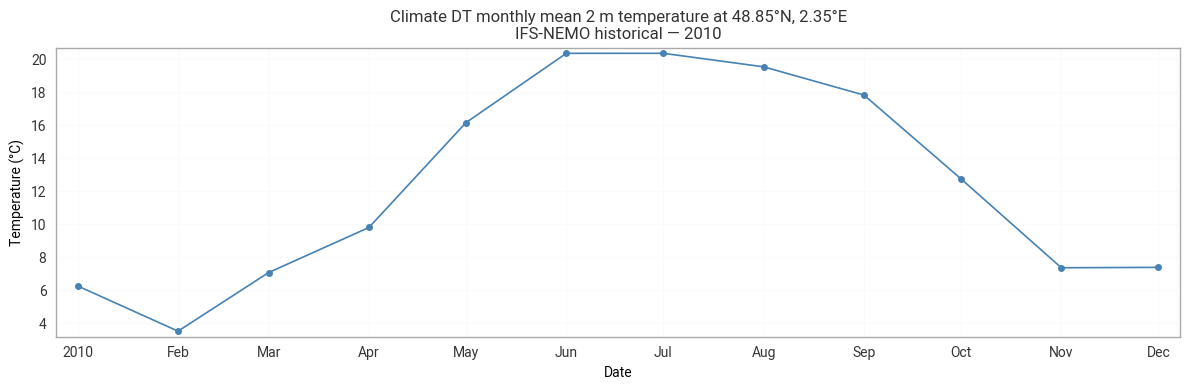

In [ ]:
# Convert K → °C and plot
da = ds[PARAM].squeeze() - 273.15

fig, ax = plt.subplots(figsize=(12, 4))
da.plot(ax=ax, marker="o", markersize=4, linewidth=1.2, color="steelblue")
ax.set_title(
    f"Climate DT monthly mean 2 m temperature at {location_to_string(LOCATION)}\n"
    f"IFS-NEMO historical — {YEARS.replace('/', ', ')}"
)
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()